In [1]:
import pandas as pd
daily_df = pd.read_csv('merged_ohlcv.csv')
daily_df['날짜'] = pd.to_datetime(daily_df['날짜'])
print(daily_df.shape)

C:\Users\tpdlq\AppData\Local\Temp\ipykernel_15124\2701149720.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  daily_df = pd.read_csv('merged_ohlcv.csv')


(3055322, 10)


In [2]:
daily_df['종목코드'] = daily_df['종목코드'].astype(str).str.zfill(6)
print(daily_df.dtypes)
print(daily_df.columns.tolist())
daily_df.head()

날짜      datetime64[ns]
종목코드            object
종목명             object
시장              object
시가               int64
고가               int64
저가               int64
종가               int64
거래량              int64
거래대금           float64
dtype: object
['날짜', '종목코드', '종목명', '시장', '시가', '고가', '저가', '종가', '거래량', '거래대금']


,날짜,종목코드,종목명,시장,시가,고가,저가,종가,거래량,거래대금
0,2021-07-12,000020,동화약품,KOSPI,15000,15150,14900,15050,160334,0.668896
1,2021-07-13,000020,동화약품,KOSPI,15050,15100,14850,14850,184810,-1.328904
2,2021-07-14,000020,동화약품,KOSPI,14950,14950,14700,14750,118825,-0.673401
3,2021-07-15,000020,동화약품,KOSPI,15000,15000,14750,14850,149813,0.677966
4,2021-07-16,000020,동화약품,KOSPI,14850,14950,14650,14800,169898,-0.336700


In [4]:
!pip install ta -q
import ta

In [5]:
def compute_rsi(series, length=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(length).mean()
    avg_loss = loss.rolling(length).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

def compute_stoch_rsi(series, length=14):
    rsi = compute_rsi(series, length)
    min_rsi = rsi.rolling(length).min()
    max_rsi = rsi.rolling(length).max()
    stoch_rsi = (rsi - min_rsi) / (max_rsi - min_rsi)
    return stoch_rsi

def compute_cmf(high, low, close, volume, length=20):
    mfm = ((close - low) - (high - close)) / (high - low).replace(0, np.nan)
    mfv = mfm * volume
    cmf = mfv.rolling(length).sum() / volume.rolling(length).sum()
    return cmf

def compute_obv(close, volume):
    direction = np.sign(close.diff()).fillna(0)
    return (direction * volume).cumsum()

In [6]:
print(daily_df['거래대금'].describe())

count    3.054809e+06
mean     1.064150e-03
std      4.549184e+00
min     -9.140271e+01
25%     -1.436130e+00
50%      0.000000e+00
75%      1.070664e+00
max      3.238028e+03
Name: 거래대금, dtype: float64


In [7]:
daily_df['거래대금_근사'] = daily_df['종가'] * daily_df['거래량']
print(daily_df['거래대금_근사'].describe())

count    3.055322e+06
mean     9.155971e+09
std      1.193239e+11
min      0.000000e+00
25%      1.443971e+08
50%      5.523876e+08
75%      2.696468e+09
max      5.436202e+13
Name: 거래대금_근사, dtype: float64


In [8]:
import numpy as np

def compute_rsi(series, length=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(length).mean()
    avg_loss = loss.rolling(length).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

def compute_stoch_rsi(series, length=14):
    rsi = compute_rsi(series, length)
    min_rsi = rsi.rolling(length).min()
    max_rsi = rsi.rolling(length).max()
    stoch_rsi = (rsi - min_rsi) / (max_rsi - min_rsi)
    return stoch_rsi

def compute_cmf(high, low, close, volume, length=20):
    range_safe = (high - low).replace(0, np.nan)
    mfm = ((close - low) - (high - close)) / range_safe
    mfv = mfm * volume
    cmf = mfv.rolling(length).sum() / volume.rolling(length).sum()
    return cmf

def compute_obv(close, volume):
    direction = np.sign(close.diff()).fillna(0)
    return (direction * volume).cumsum()

def add_technical_indicators(g):
    g = g.sort_values('날짜').copy()

    g['RSI'] = compute_rsi(g['종가'])
    g['StochRSI'] = compute_stoch_rsi(g['종가'])
    macd, macd_signal, macd_hist = compute_macd(g['종가'])
    g['MACD'] = macd
    g['MACD_signal'] = macd_signal
    g['MACD_hist'] = macd_hist
    g['CMF'] = compute_cmf(g['고가'], g['저가'], g['종가'], g['거래량'])
    g['OBV'] = compute_obv(g['종가'], g['거래량'])

    g['MA20'] = g['종가'].rolling(20).mean()
    g['MA60'] = g['종가'].rolling(60).mean()
    g['MA20_이격도'] = (g['종가'] - g['MA20']) / g['MA20'] * 100

    rolling_high = g['고가'].rolling(60).max()
    rolling_low = g['저가'].rolling(60).min()
    fib_range = (rolling_high - rolling_low).replace(0, np.nan)
    g['피보나치위치'] = (g['종가'] - rolling_low) / fib_range

    g['거래량_20일평균대비'] = g['거래량'] / g['거래량'].rolling(20).mean()
    g['거래대금_20일평균대비'] = g['거래대금_근사'] / g['거래대금_근사'].rolling(20).mean()

    return g

In [9]:
enriched_list = []
tickers = daily_df['종목코드'].unique()
for i, ticker in enumerate(tickers):
    g = daily_df[daily_df['종목코드'] == ticker]
    if len(g) < 60:
        continue
    enriched_list.append(add_technical_indicators(g))
    if i % 300 == 0:
        print(f"진행률: {i}/{len(tickers)}")

daily_enriched = pd.concat(enriched_list, ignore_index=True)
print(daily_enriched.shape)

진행률: 0/2765
진행률: 300/2765
진행률: 600/2765
진행률: 900/2765
진행률: 1200/2765
진행률: 1500/2765
진행률: 1800/2765
진행률: 2100/2765
진행률: 2400/2765
진행률: 2700/2765
(3054885, 24)


In [10]:
daily_enriched = daily_enriched.sort_values(['종목코드','날짜']).reset_index(drop=True)

daily_enriched['전일종가'] = daily_enriched.groupby('종목코드')['종가'].shift(1)
daily_enriched['등락률'] = (daily_enriched['종가'] - daily_enriched['전일종가']) / daily_enriched['전일종가'] * 100

daily_enriched['다음날_시가'] = daily_enriched.groupby('종목코드')['시가'].shift(-1)
daily_enriched['다음날_날짜'] = daily_enriched.groupby('종목코드')['날짜'].shift(-1)
daily_enriched['날짜차이'] = (daily_enriched['다음날_날짜'] - daily_enriched['날짜']).dt.days

daily_enriched['갭퍼센트'] = (daily_enriched['다음날_시가'] - daily_enriched['종가']) / daily_enriched['종가'] * 100

df_clean2 = daily_enriched[
    (daily_enriched['날짜차이'] <= 5) &
    (daily_enriched['다음날_시가'] > 0) &
    (daily_enriched['등락률'].notna())
].copy()

# 이전에 확인한 정제 규칙 (우선주 제외, 저가주 제외, 가격제한폭 캡)
df_clean2 = df_clean2[~df_clean2['종목명'].str.contains('우$|우B$|1우|2우', regex=True, na=False)]
df_clean2 = df_clean2[df_clean2['종가'] >= 1000]
df_clean2 = df_clean2[(df_clean2['갭퍼센트'] >= -30) & (df_clean2['갭퍼센트'] <= 30)]

print(df_clean2.shape)

(2800819, 30)


In [11]:
TH = 23
gap_events = df_clean2[df_clean2['등락률'] >= TH].copy()
print(f"{TH}%+ 갭전략 이벤트: {len(gap_events)}건")
print(gap_events[['RSI','StochRSI','MACD_hist','CMF','MA20_이격도','피보나치위치',
                   '거래량_20일평균대비','거래대금_20일평균대비']].describe())

23%+ 갭전략 이벤트: 7821건
               RSI     StochRSI     MACD_hist          CMF     MA20_이격도  \
count  7605.000000  7353.000000   7821.000000  6671.000000  7552.000000   
mean     74.214418     0.906884    365.801108     0.371547    37.702974   
std      13.858284     0.201950   1492.737952     0.296156    37.028672   
min      10.700758     0.000000 -16722.551351    -0.651501   -61.548234   
25%      66.216216     0.956541     46.285353     0.155214    22.657751   
50%      76.085118     1.000000    120.297833     0.359011    31.027031   
75%      84.210526     1.000000    308.122644     0.591710    43.864624   
max     100.000000     1.000000  54038.542306     0.992192  1170.300691   

            피보나치위치  거래량_20일평균대비  거래대금_20일평균대비  
count  7291.000000  7552.000000   7552.000000  
mean      0.837687     8.206978      9.133251  
std       0.227035     5.224018      5.297415  
min       0.052762     0.000324      0.000480  
25%       0.716813     3.699748      4.547861  
50%       0.9569

In [12]:
gap_events['날짜dt'] = pd.to_datetime(gap_events['날짜'])
split_date = gap_events['날짜dt'].median()

train = gap_events[gap_events['날짜dt'] < split_date].copy()
test = gap_events[gap_events['날짜dt'] >= split_date].copy()

print(f"학습: {len(train)}건 ({train['날짜dt'].min()} ~ {train['날짜dt'].max()})")
print(f"검증: {len(test)}건 ({test['날짜dt'].min()} ~ {test['날짜dt'].max()})")

feature_cols_daily = ['RSI','StochRSI','MACD_hist','CMF','MA20_이격도',
                       '피보나치위치','거래량_20일평균대비','거래대금_20일평균대비']

X_train = train[feature_cols_daily].fillna(train[feature_cols_daily].median())
y_train = train['갭퍼센트']
X_test = test[feature_cols_daily].fillna(train[feature_cols_daily].median())
y_test = test['갭퍼센트']

학습: 3910건 (2021-07-13 00:00:00 ~ 2024-09-06 00:00:00)
검증: 3911건 (2024-09-09 00:00:00 ~ 2026-07-09 00:00:00)


In [13]:

import lightgbm as lgb

model = lgb.LGBMRegressor(max_depth=4, n_estimators=100, min_child_samples=30, random_state=42)
model.fit(X_train, y_train)

pred_test = model.predict(X_test)
print(f"검증 상관관계: {pd.Series(pred_test, index=test.index).corr(y_test):.4f}")
print(f"검증 R²: {model.score(X_test, y_test):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 3910, number of used features: 8
[LightGBM] [Info] Start training from score 4.835738
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [14]:
test_copy = test.copy()
test_copy['예측갭'] = pred_test

test_copy['예측등급'] = pd.qcut(test_copy['예측갭'], q=5, labels=['하위20%','20-40%','40-60%','60-80%','상위20%'])
print(test_copy.groupby('예측등급')['갭퍼센트'].agg(['count','mean']))

        count       mean
예측등급                    
하위20%     783   2.217484
20-40%    782   4.571099
40-60%    782   5.333522
60-80%    782   6.804144
상위20%     782  11.933648


C:\Users\tpdlq\AppData\Local\Temp\ipykernel_15124\3588767022.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(test_copy.groupby('예측등급')['갭퍼센트'].agg(['count','mean']))


In [17]:
!pip install shap -q


c:\Users\tpdlq\Documents\Code Studio\create\venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\tpdlq\Documents\Code Studio\create\venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\tpdlq\Documents\Code Studio\create\venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\tpdlq\Documents\Code Studio\create\venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\tpdlq\Documents\Code Studio\create\venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.t

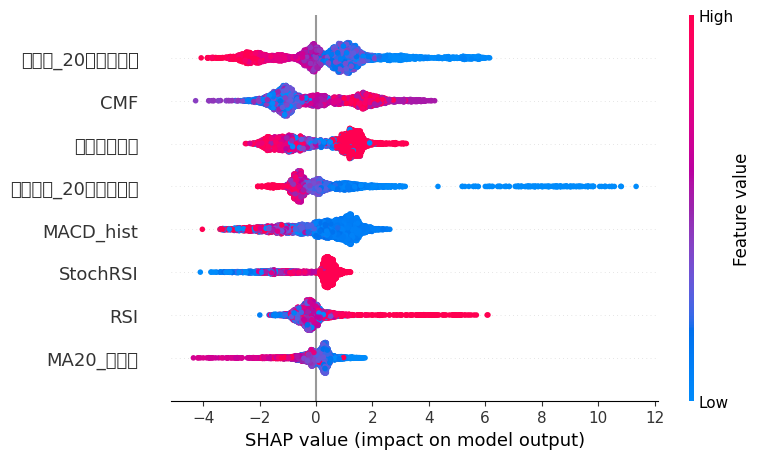

In [18]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [19]:
importance_df = pd.DataFrame({
    '피처': feature_cols_daily,
    '중요도': model.feature_importances_
}).sort_values('중요도', ascending=False)
print(importance_df)

             피처  중요도
3           CMF  177
2     MACD_hist  162
4      MA20_이격도  143
0           RSI  132
6   거래량_20일평균대비  121
5        피보나치위치  118
7  거래대금_20일평균대비  111
1      StochRSI   81


In [20]:
top20 = test_copy[test_copy['예측등급']=='상위20%']
bottom20 = test_copy[test_copy['예측등급']=='하위20%']

for col in feature_cols_daily:
    print(f"{col}: 상위20% 평균={top20[col].mean():.2f}, 하위20% 평균={bottom20[col].mean():.2f}")

RSI: 상위20% 평균=75.37, 하위20% 평균=72.70
StochRSI: 상위20% 평균=0.91, 하위20% 평균=0.84
MACD_hist: 상위20% 평균=274.37, 하위20% 평균=794.96
CMF: 상위20% 평균=0.19, 하위20% 평균=0.32
MA20_이격도: 상위20% 평균=54.02, 하위20% 평균=35.55
피보나치위치: 상위20% 평균=0.81, 하위20% 평균=0.86
거래량_20일평균대비: 상위20% 평균=3.72, 하위20% 평균=8.17
거래대금_20일평균대비: 상위20% 평균=4.56, 하위20% 평균=9.12


In [21]:
filtered = test_copy[
    (test_copy['거래량_20일평균대비'] < 5) &
    (test_copy['MA20_이격도'] > 40)
]
print(f"필터 통과 건수: {len(filtered)}")
print(f"필터 통과 그룹 평균갭: {filtered['갭퍼센트'].mean():.2f}%")
print(f"전체 평균갭 (비교): {test_copy['갭퍼센트'].mean():.2f}%")

필터 통과 건수: 701
필터 통과 그룹 평균갭: 8.59%
전체 평균갭 (비교): 6.17%


In [22]:
filtered_copy = filtered.copy()
filtered_copy['연도'] = filtered_copy['날짜dt'].dt.year

print(filtered_copy.groupby('연도')['갭퍼센트'].agg(['count','mean']))
print(f"\n전체 필터 승률(갭상승 비율): {(filtered_copy['갭퍼센트']>0).mean()*100:.1f}%")

      count       mean
연도                    
2024     71  11.014229
2025    227   8.912918
2026    403   7.976829

전체 필터 승률(갭상승 비율): 73.8%


In [23]:
TAX_FEE = 0.21
filtered_after_cost = filtered_copy['갭퍼센트'] - TAX_FEE
print(f"세후 평균: {filtered_after_cost.mean():.2f}%")
print(f"세후 승률: {(filtered_after_cost>0).mean()*100:.1f}%")

세후 평균: 8.38%
세후 승률: 73.2%


새로운 분석 각도 4가지
1. 오늘의 두 발견을 결합 — 이게 제일 유망함
일봉 분석에서 "거래량 상대적으로 적음 + MA20 이격도 큼(강한 기존추세)" 필터가 갭전략을 개선시켰잖아. 이 조건을 장중 추격매수의 사전 필터로 적용해보는 거야:
python# 장중 이벤트 발생 종목 중, 그 종목의 "일봉 레벨" 조건도 좋은 것만 추림
# 즉 "오늘 아침에 이미 강한 추세(MA20이격도 큼) + 거래량이 과도하지 않은" 종목만 추격매수 후보로
가설: 지금까지 장중 추격매수가 실패한 건 "아무 급등 종목이나" 다 봤기 때문이고, 이미 검증된 "건강한 추세" 필터를 먼저 통과한 종목만 골라서 장중 추격하면 결과가 달라질 수 있음
2. 눌림목 진입 (Breakout-chase 대신 Pullback-entry)
지금까지는 "임계값 도달하는 순간 즉시 매수"였는데, 대신 **"도달 후 첫 조정(눌림)이 나올 때까지 기다렸다가, 그 반등 시점에 진입"**하는 방식:
1) 09~14시 사이 임계값 도달 감지
2) 이후 첫 음봉(조정) 발생 대기
3) 그 다음 봉이 다시 양봉으로 전환하는 순간 진입 (되돌림 후 재상승 확인)
이건 "이미 달릴 대로 달린 것"을 쫓지 않고 "숨 고르기 후 재출발"을 잡는 거라, 오늘 결정트리에서 확인된 "종가까지 대부분 조정이 온다"는 사실을 오히려 이용하는 접근
3. 다중 시간대 확인 (30분봉 추세 + 10분봉 타이밍)

30분봉으로 "상위 추세"가 진짜 강한지 확인 (예: 30분봉 3개 연속 고점 갱신)
그 조건을 만족할 때만, 10분봉에서 구체적 진입 타이밍(거래량 터지는 순간) 포착
이러면 "노이즈성 단기 급등"과 "진짜 추세 있는 급등"을 구분 가능할 수 있음

4. 상대강도(시장 대비) 필터
지금까지는 개별 종목만 봤는데, 그 시각의 코스피/코스닥 지수도 같이 급등 중이었는지 확인:
- 시장 전체가 강세일 때 개별종목 급등 → "묻어가는 상승", 시장 조정 시 같이 빠질 위험
- 시장은 잠잠한데 개별종목만 급등 → "진짜 종목 고유 이슈", 더 독립적으로 유지될 가능성
승현님이 이미 marcap 데이터 갖고 계시니, 코스피/코스닥 지수 대용치(전체 종목 평균 등락률)를 만들어서 비교 가능


##추가 분석 code

In [1]:
import pandas as pd
import numpy as np

# 시간봉
df = pd.read_csv('merged_hourly.csv')
df['cntr_tm'] = pd.to_datetime(df['cntr_tm'], errors='coerce')
df = df.dropna(subset=['cntr_tm'])
df['날짜'] = df['cntr_tm'].dt.date
df = df.sort_values(['종목코드','cntr_tm']).reset_index(drop=True)

daily_close = df.groupby(['종목코드','날짜'])['cur_prc'].last().reset_index()
daily_close = daily_close.sort_values(['종목코드','날짜'])
daily_close['전일종가'] = daily_close.groupby('종목코드')['cur_prc'].shift(1)
df = df.merge(daily_close[['종목코드','날짜','전일종가']], on=['종목코드','날짜'], how='left')
df['누적등락률'] = (df['cur_prc'] - df['전일종가']) / df['전일종가'] * 100
df_sorted = df.sort_values(['종목코드','날짜','cntr_tm']).reset_index(drop=True)
day_groups = {k: v for k, v in df_sorted.groupby(['종목코드','날짜'])}

print(f"시간봉: {df_sorted.shape}")

시간봉: (4578822, 13)


In [2]:
daily_df = pd.read_csv('merged_ohlcv.csv')
daily_df['종목코드'] = daily_df['종목코드'].astype(str).str.zfill(6)
daily_df['날짜'] = pd.to_datetime(daily_df['날짜'])
daily_df['거래대금_근사'] = daily_df['종가'] * daily_df['거래량']

def compute_rsi(series, length=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(length).mean()
    avg_loss = loss.rolling(length).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def add_indicators(g):
    g = g.sort_values('날짜').copy()
    g['MA20'] = g['종가'].rolling(20).mean()
    g['MA20_이격도'] = (g['종가'] - g['MA20']) / g['MA20'] * 100
    g['거래량_20일평균'] = g['거래량'].rolling(20).mean()
    g['거래량_20일평균대비'] = g['거래량'] / g['거래량_20일평균']
    return g

enriched_list = []
for ticker, g in daily_df.groupby('종목코드'):
    if len(g) < 60:
        continue
    enriched_list.append(add_indicators(g))

daily_enriched = pd.concat(enriched_list, ignore_index=True)
daily_enriched['날짜'] = daily_enriched['날짜'].dt.date  # 시간봉 날짜(date)와 타입 통일
print(f"일봉: {daily_enriched.shape}")

C:\Users\tpdlq\AppData\Local\Temp\ipykernel_11004\610094654.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  daily_df = pd.read_csv('merged_ohlcv.csv')


일봉: (3054885, 15)


In [5]:
daily_enriched_sorted = daily_enriched.sort_values(['종목코드','날짜'])
daily_enriched_sorted['전일MA20이격도'] = daily_enriched_sorted.groupby('종목코드')['MA20_이격도'].shift(1)
daily_enriched_sorted['전일거래량비율'] = daily_enriched_sorted.groupby('종목코드')['거래량_20일평균대비'].shift(1)

indicator_lookup = daily_enriched_sorted[['종목코드','날짜','전일MA20이격도','전일거래량비율']].copy()
indicator_lookup['종목코드'] = indicator_lookup['종목코드'].astype(str).str.zfill(6)

TH = 23
hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
first_hit = hit.groupby(['종목코드','날짜']).first().reset_index()
first_hit['종목코드'] = first_hit['종목코드'].astype(str).str.zfill(6)

first_hit = first_hit.merge(indicator_lookup, on=['종목코드','날짜'], how='left')
print(f"매칭 성공: {first_hit['전일MA20이격도'].notna().sum()} / {len(first_hit)}")

매칭 성공: 3859 / 3973


In [9]:
print("진입수익률 계산 후 결측 아닌 개수:", first_hit['진입수익률'].notna().sum())
print("전체 건수:", len(first_hit))
print(first_hit[['진입수익률','전일MA20이격도','전일거래량비율']].isna().sum())

진입수익률 계산 후 결측 아닌 개수: 0
전체 건수: 0
진입수익률        0
전일MA20이격도    0
전일거래량비율      0
dtype: int64


In [11]:
daily_enriched_sorted = daily_enriched.sort_values(['종목코드','날짜'])
daily_enriched_sorted['전일MA20이격도'] = daily_enriched_sorted.groupby('종목코드')['MA20_이격도'].shift(1)
daily_enriched_sorted['전일거래량비율'] = daily_enriched_sorted.groupby('종목코드')['거래량_20일평균대비'].shift(1)

indicator_lookup = daily_enriched_sorted[['종목코드','날짜','전일MA20이격도','전일거래량비율']].copy()
indicator_lookup['종목코드'] = indicator_lookup['종목코드'].astype(str).str.zfill(6)

TH = 23
hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
first_hit = hit.groupby(['종목코드','날짜']).first().reset_index()
first_hit['종목코드'] = first_hit['종목코드'].astype(str).str.zfill(6)

first_hit = first_hit.merge(indicator_lookup, on=['종목코드','날짜'], how='left')
print(f"매칭 성공: {first_hit['전일MA20이격도'].notna().sum()} / {len(first_hit)}")

매칭 성공: 3859 / 3973


In [12]:
def get_final_return(row):
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    if day_data is None:
        return None
    bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
    if len(bar_1500) == 0:
        return None
    close_1500 = bar_1500.iloc[0]['cur_prc']
    return (close_1500 - row['cur_prc']) / row['cur_prc'] * 100

for i in range(5):
    row = first_hit.iloc[i]
    key = (row['종목코드'], row['날짜'])
    print(f"키: {key}, day_groups에 있음: {key in day_groups}")
    if key in day_groups:
        dd = day_groups[key]
        print(f"  15시봉 개수: {len(dd[dd['cntr_tm'].dt.hour==15])}")

키: ('000040', datetime.date(2025, 7, 22)), day_groups에 있음: False
키: ('000040', datetime.date(2025, 7, 30)), day_groups에 있음: False
키: ('000050', datetime.date(2025, 12, 12)), day_groups에 있음: False
키: ('000050', datetime.date(2025, 12, 15)), day_groups에 있음: False
키: ('000210', datetime.date(2026, 3, 20)), day_groups에 있음: False


In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged_hourly.csv')
df['종목코드'] = df['종목코드'].astype(str).str.zfill(6)   # <- 이 줄이 핵심
df['cntr_tm'] = pd.to_datetime(df['cntr_tm'], errors='coerce')
df = df.dropna(subset=['cntr_tm'])
df['날짜'] = df['cntr_tm'].dt.date
df = df.sort_values(['종목코드','cntr_tm']).reset_index(drop=True)

daily_close = df.groupby(['종목코드','날짜'])['cur_prc'].last().reset_index()
daily_close = daily_close.sort_values(['종목코드','날짜'])
daily_close['전일종가'] = daily_close.groupby('종목코드')['cur_prc'].shift(1)
df = df.merge(daily_close[['종목코드','날짜','전일종가']], on=['종목코드','날짜'], how='left')
df['누적등락률'] = (df['cur_prc'] - df['전일종가']) / df['전일종가'] * 100
df_sorted = df.sort_values(['종목코드','날짜','cntr_tm']).reset_index(drop=True)
day_groups = {k: v for k, v in df_sorted.groupby(['종목코드','날짜'])}

print(f"시간봉: {df_sorted.shape}")
print(f"종목코드 타입 확인: {type(list(day_groups.keys())[0][0])}")

시간봉: (4578822, 13)
종목코드 타입 확인: <class 'str'>


In [15]:
daily_df = pd.read_csv('merged_ohlcv.csv')
daily_df['종목코드'] = daily_df['종목코드'].astype(str).str.zfill(6)
daily_df['날짜'] = pd.to_datetime(daily_df['날짜'])
daily_df['거래대금_근사'] = daily_df['종가'] * daily_df['거래량']

def add_indicators(g):
    g = g.sort_values('날짜').copy()
    g['MA20'] = g['종가'].rolling(20).mean()
    g['MA20_이격도'] = (g['종가'] - g['MA20']) / g['MA20'] * 100
    g['거래량_20일평균'] = g['거래량'].rolling(20).mean()
    g['거래량_20일평균대비'] = g['거래량'] / g['거래량_20일평균']
    return g

enriched_list = []
for ticker, g in daily_df.groupby('종목코드'):
    if len(g) < 60:
        continue
    enriched_list.append(add_indicators(g))

daily_enriched = pd.concat(enriched_list, ignore_index=True)
daily_enriched['종목코드'] = daily_enriched['종목코드'].astype(str).str.zfill(6)
daily_enriched['날짜'] = daily_enriched['날짜'].dt.date

print(f"일봉: {daily_enriched.shape}")
print(f"종목코드 타입: {type(daily_enriched['종목코드'].iloc[0])}")

C:\Users\tpdlq\AppData\Local\Temp\ipykernel_11004\1746237481.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  daily_df = pd.read_csv('merged_ohlcv.csv')


일봉: (3054885, 15)
종목코드 타입: <class 'str'>


In [16]:
daily_enriched_sorted = daily_enriched.sort_values(['종목코드','날짜'])
daily_enriched_sorted['전일MA20이격도'] = daily_enriched_sorted.groupby('종목코드')['MA20_이격도'].shift(1)
daily_enriched_sorted['전일거래량비율'] = daily_enriched_sorted.groupby('종목코드')['거래량_20일평균대비'].shift(1)

indicator_lookup = daily_enriched_sorted[['종목코드','날짜','전일MA20이격도','전일거래량비율']].copy()
indicator_lookup['종목코드'] = indicator_lookup['종목코드'].astype(str).str.zfill(6)

TH = 23
hit = df_sorted[df_sorted['누적등락률'] >= TH].copy()
first_hit = hit.groupby(['종목코드','날짜']).first().reset_index()
first_hit['종목코드'] = first_hit['종목코드'].astype(str).str.zfill(6)

first_hit = first_hit.merge(indicator_lookup, on=['종목코드','날짜'], how='left')
print(f"매칭 성공: {first_hit['전일MA20이격도'].notna().sum()} / {len(first_hit)}")

매칭 성공: 3859 / 3973


In [17]:
def get_final_return(row):
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    if day_data is None:
        return None
    bar_1500 = day_data[day_data['cntr_tm'].dt.hour == 15]
    if len(bar_1500) == 0:
        return None
    close_1500 = bar_1500.iloc[0]['cur_prc']
    return (close_1500 - row['cur_prc']) / row['cur_prc'] * 100

first_hit['진입수익률'] = first_hit.apply(get_final_return, axis=1)
first_hit_clean = first_hit.dropna(subset=['진입수익률', '전일MA20이격도', '전일거래량비율']).copy()

print(f"최종 분석 대상: {len(first_hit_clean)}건")

first_hit_clean['일봉필터통과'] = (
    (first_hit_clean['전일거래량비율'] < 5) & (first_hit_clean['전일MA20이격도'] > 40)
)

print(first_hit_clean.groupby('일봉필터통과')['진입수익률'].agg(['count','mean']))
print(f"\n필터통과 승률: {(first_hit_clean[first_hit_clean['일봉필터통과']]['진입수익률']>0).mean()*100:.1f}%")
print(f"필터미통과 승률: {(first_hit_clean[~first_hit_clean['일봉필터통과']]['진입수익률']>0).mean()*100:.1f}%")

최종 분석 대상: 3852건
        count      mean
일봉필터통과                 
False    3566 -2.154567
True      286 -2.505694

필터통과 승률: 20.3%
필터미통과 승률: 24.0%


이건 명확한 답이 나왔어 — 1번 가설(일봉 레벨 좋은 조건 필터를 장중 추격매수에 결합)은 기각이야. 오히려 반대 방향으로 나왔어.
결과
그룹건수평균수익률승률필터미통과3,566-2.15%24.0%필터통과286-2.51%20.3%
필터를 통과한 그룹(일봉 레벨에서 "좋은 조건"이었던 종목)이 오히려 더 나쁜 결과를 보였어 — 평균수익률도 더 낮고, 승률도 더 낮아.
왜 이런 역설이 생기는지 — 해석
이건 사실 논리적으로 설명이 돼:

일봉 필터(거래량 적음+MA20 이격도 큼)는 **"익일 갭이 크게 벌어질 가능성이 높은 종목"**을 찾는 필터였어 — 즉 "내일 더 오를 가능성이 높다"는 신호
근데 장중 추격매수는 **"오늘 이미 오른 만큼을 오늘 종가까지 유지하는지"**를 보는 거야 — 완전히 다른 질문
오히려 이 필터에 걸리는 종목들은 "거래량이 적은데도 크게 오른" 상태인데, 이건 장중 관점에서는 **"매수 주체가 얇다"**는 뜻일 수도 있어 — 소수의 매수세로 밀어올린 가격이라, 장중에 잠깐이라도 매도 물량이 나오면 오히려 쉽게 반납될 수 있음

핵심 통찰: "다음날 갭이 잘 벌어지는 조건"과 "오늘 하루 안에서 상승분을 유지하는 조건"은 서로 다른, 심지어 상충하는 메커니즘일 수 있다는 거야. 익일갭 전략에서 좋았던 신호를 장중 전략에 그대로 가져다 쓰면 안 된다는 게 이번 검증의 핵심 교훈이야.
1번은 기각으로 정리하고, 2번(눌림목 진입)으로 넘어갈까?

In [18]:
def pullback_entry_return(row):
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    if day_data is None:
        return None

    event_time = row['cntr_tm']
    post = day_data[day_data['cntr_tm'] > event_time].reset_index(drop=True)
    if len(post) == 0:
        return None

    # 1) 이벤트 이후 첫 음봉(조정) 찾기
    first_bear_idx = None
    for i in range(len(post)):
        bar = post.iloc[i]
        if bar['cur_prc'] < bar['open_pric']:
            first_bear_idx = i
            break

    if first_bear_idx is None:
        return None  # 조정 자체가 없었음 (끝까지 양봉만) -> 눌림목 진입 기회 자체가 없는 케이스

    # 2) 그 다음 봉이 양봉으로 전환하는 시점 찾기
    entry_idx = None
    for j in range(first_bear_idx + 1, len(post)):
        bar = post.iloc[j]
        if bar['cur_prc'] > bar['open_pric']:
            entry_idx = j
            break

    if entry_idx is None:
        return None  # 재상승 전환이 하루 안에 안 나타남

    entry_price = post.iloc[entry_idx]['cur_prc']
    final_price = post.iloc[-1]['cur_prc']
    return (final_price - entry_price) / entry_price * 100

first_hit['눌림목진입수익률'] = first_hit.apply(pullback_entry_return, axis=1)

pullback_valid = first_hit.dropna(subset=['눌림목진입수익률'])
print(f"눌림목 진입 가능 케이스: {len(pullback_valid)} / 전체 {len(first_hit)}")
print(pullback_valid['눌림목진입수익률'].describe())
print(f"\n평균: {pullback_valid['눌림목진입수익률'].mean():.3f}%")
print(f"승률: {(pullback_valid['눌림목진입수익률']>0).mean()*100:.1f}%")

눌림목 진입 가능 케이스: 1331 / 전체 3973
count    1331.000000
mean       -1.182058
std         4.383049
min       -30.240700
25%        -1.833182
50%         0.000000
75%         0.264075
max        14.963880
Name: 눌림목진입수익률, dtype: float64

평균: -1.182%
승률: 27.0%


In [19]:
wins = pullback_valid[pullback_valid['눌림목진입수익률']>0]['눌림목진입수익률']
losses = pullback_valid[pullback_valid['눌림목진입수익률']<=0]['눌림목진입수익률']
print(f"평균 승리: {wins.mean():.2f}%, 평균 손실: {losses.mean():.2f}%")
print(f"손익비: {abs(wins.mean()/losses.mean()):.2f}")

# 워크포워드 분리
pullback_valid = pullback_valid.copy()
pullback_valid['날짜dt'] = pd.to_datetime(pullback_valid['날짜'])
split_date = pullback_valid['날짜dt'].median()
train_p = pullback_valid[pullback_valid['날짜dt'] < split_date]
test_p = pullback_valid[pullback_valid['날짜dt'] >= split_date]

print(f"\n학습기간({len(train_p)}건) 평균: {train_p['눌림목진입수익률'].mean():.3f}%")
print(f"검증기간({len(test_p)}건) 평균: {test_p['눌림목진입수익률'].mean():.3f}%")

평균 승리: 2.44%, 평균 손실: -2.52%
손익비: 0.97

학습기간(657건) 평균: -1.114%
검증기간(674건) 평균: -1.248%


In [20]:
# 시간대별 전체 시장 평균 등락률 (그 시각까지의 누적등락률 평균)
market_avg = df_sorted.groupby('cntr_tm')['누적등락률'].mean().reset_index()
market_avg.columns = ['cntr_tm', '시장평균등락률']

# first_hit에 이벤트 시점의 시장평균등락률 결합
first_hit_market = first_hit.merge(market_avg, on='cntr_tm', how='left')
first_hit_market['상대강도'] = first_hit_market['누적등락률'] - first_hit_market['시장평균등락률']

print(first_hit_market[['종목코드','날짜','cntr_tm','누적등락률','시장평균등락률','상대강도']].head(10))
print(first_hit_market['상대강도'].describe())

     종목코드          날짜             cntr_tm      누적등락률   시장평균등락률       상대강도
0  000040  2025-07-22 2025-07-22 10:00:00  23.595506 -0.191456  23.786962
1  000040  2025-07-30 2025-07-30 09:00:00  29.821074  0.464170  29.356903
2  000050  2025-12-12 2025-12-12 09:00:00  29.988194  0.401757  29.586436
3  000050  2025-12-15 2025-12-15 09:00:00  25.794732 -0.159317  25.954049
4  000210  2026-03-20 2026-03-20 09:00:00  23.976608  1.526291  22.450317
5  000230  2025-07-07 2025-07-07 14:00:00  26.430518 -0.092366  26.522884
6  000230  2025-09-29 2025-09-29 10:00:00  29.989213  0.952194  29.037018
7  000230  2025-11-05 2025-11-05 13:00:00  29.392265 -1.865172  31.257437
8  000230  2025-12-11 2025-12-11 12:00:00  23.054114  0.682282  22.371833
9  000250  2025-07-23 2025-07-23 09:00:00  29.708384 -0.976907  30.685291
count    3973.000000
mean       27.037087
std         3.346030
min        14.348989
25%        24.504868
50%        27.487281
75%        29.743585
max        38.610780
Name: 상대강도, dtype:

In [22]:
first_hit_market = first_hit_market.merge(
    first_hit[['종목코드','날짜','진입수익률']] if '진입수익률' in first_hit.columns else pd.DataFrame(),
    on=['종목코드','날짜'], how='left'
) if '진입수익률' not in first_hit_market.columns else first_hit_market

# 진입수익률이 없으면 다시 계산
if '진입수익률' not in first_hit_market.columns or first_hit_market['진입수익률'].isna().all():
    first_hit_market['진입수익률'] = first_hit_market.apply(get_final_return, axis=1)

valid = first_hit_market.dropna(subset=['진입수익률', '상대강도']).copy()
print(f"분석 대상: {len(valid)}건")

# 상대강도를 4분위로 나눠서 비교
valid['상대강도_구간'] = pd.qcut(valid['상대강도'], q=4, labels=['하위25%','25-50%','50-75%','상위25%'])
print(valid.groupby('상대강도_구간')['진입수익률'].agg(['count','mean']))

분석 대상: 3969건
         count      mean
상대강도_구간                 
하위25%      993 -1.930964
25-50%     992 -2.239620
50-75%     992 -2.526239
상위25%      992 -1.944775


C:\Users\tpdlq\AppData\Local\Temp\ipykernel_11004\261039787.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(valid.groupby('상대강도_구간')['진입수익률'].agg(['count','mean']))


In [23]:
def measure_pullback_depth(row):
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    if day_data is None:
        return None

    event_time = row['cntr_tm']
    post = day_data[day_data['cntr_tm'] > event_time].reset_index(drop=True)
    if len(post) == 0:
        return None

    event_price = row['cur_prc']
    running_high = event_price  # 이벤트 시점까지의 고점 (이벤트가격을 기준점으로)

    for i in range(len(post)):
        bar = post.iloc[i]
        running_high = max(running_high, bar['high_pric'])

        is_bearish = bar['cur_prc'] < bar['open_pric']
        if is_bearish:
            pullback_depth = (running_high - bar['low_pric']) / running_high * 100
            return {
                '눌림목발생': True,
                '눌림목까지봉수': i,
                '눌림목깊이': pullback_depth,
                '눌림목시각': bar['cntr_tm'].hour,
                '눌림목봉거래량': bar['trde_qty'],
            }

    # 끝까지 눌림목(음봉) 자체가 없었던 경우
    return {'눌림목발생': False, '눌림목까지봉수': None, '눌림목깊이': None,
            '눌림목시각': None, '눌림목봉거래량': None}

pullback_results = []
for _, row in first_hit.iterrows():
    r = measure_pullback_depth(row)
    if r is None:
        continue
    r['종목코드'] = row['종목코드']
    r['날짜'] = row['날짜']
    pullback_results.append(r)

pullback_df = pd.DataFrame(pullback_results)
print(f"전체: {len(pullback_df)}건")
print(f"눌림목 발생: {pullback_df['눌림목발생'].sum()}건 ({pullback_df['눌림목발생'].mean()*100:.1f}%)")
print(f"\n눌림목 깊이 분포:")
print(pullback_df[pullback_df['눌림목발생']]['눌림목깊이'].describe())

전체: 3855건
눌림목 발생: 2014건 (52.2%)

눌림목 깊이 분포:
count    2014.000000
mean        6.825639
std         4.171808
min         0.473934
25%         3.862820
50%         5.787885
75%         8.651249
max        40.127971
Name: 눌림목깊이, dtype: float64


In [24]:
occurred = pullback_df[pullback_df['눌림목발생']].copy()

# 1) 눌림목이 몇 번째 봉에서 발생하는지 (도달 후 얼마나 빨리 조정이 오는지)
print("눌림목까지봉수 분포:")
print(occurred['눌림목까지봉수'].value_counts().sort_index())

# 2) 눌림목 시각대별 분포 (몇 시에 조정이 잘 나오는지)
print("\n눌림목 발생 시각 분포:")
print(occurred['눌림목시각'].value_counts().sort_index())

# 3) 눌림목 깊이와 눌림목까지봉수의 관계 (빨리 오는 조정이 더 깊은지 얕은지)
print("\n눌림목까지봉수별 평균 깊이:")
print(occurred.groupby('눌림목까지봉수')['눌림목깊이'].agg(['count','mean']))

눌림목까지봉수 분포:
눌림목까지봉수
0.0    1443
1.0     369
2.0     112
3.0      51
4.0      23
5.0      16
Name: count, dtype: int64

눌림목 발생 시각 분포:
눌림목시각
10.0    416
11.0    379
12.0    286
13.0    299
14.0    295
15.0    337
16.0      2
Name: count, dtype: int64

눌림목까지봉수별 평균 깊이:
         count       mean
눌림목까지봉수                  
0.0       1443   6.970118
1.0        369   5.854745
2.0        112   5.625935
3.0         51   8.424656
4.0         23  10.027810
5.0         16  14.884697


In [25]:
# 조정 시점(눌림목봉 저가)에서 매수했다고 가정, 그 이후 반등 여부 확인
def pullback_recovery(row_traj_info, df_row):
    day_data = day_groups.get((df_row['종목코드'], df_row['날짜']))
    if day_data is None:
        return None
    event_time = df_row['cntr_tm']
    post = day_data[day_data['cntr_tm'] > event_time].reset_index(drop=True)

    running_high = df_row['cur_prc']
    for i in range(len(post)):
        bar = post.iloc[i]
        running_high = max(running_high, bar['high_pric'])
        if bar['cur_prc'] < bar['open_pric']:
            entry_price = bar['low_pric']  # 눌림목 저가에 매수했다고 가정 (이상적 시나리오)
            final_price = day_data['cur_prc'].iloc[-1]
            return (final_price - entry_price) / entry_price * 100, i

    return None, None

results = []
for _, row in first_hit.iterrows():
    ret, bars_to = pullback_recovery(None, row)
    if ret is None:
        continue
    results.append({'종목코드': row['종목코드'], '날짜': row['날짜'],
                     '저점매수수익률': ret, '눌림목까지봉수': bars_to})

recovery_df = pd.DataFrame(results)
recovery_df['빠른눌림'] = recovery_df['눌림목까지봉수'] <= 2

print(recovery_df.groupby('빠른눌림')['저점매수수익률'].agg(['count','mean']))

       count      mean
빠른눌림                  
False     90  0.776837
True    1924  0.554771


In [26]:
print(recovery_df['저점매수수익률'].describe())

wins = recovery_df[recovery_df['저점매수수익률']>0]['저점매수수익률']
losses = recovery_df[recovery_df['저점매수수익률']<=0]['저점매수수익률']
print(f"\n승률: {(recovery_df['저점매수수익률']>0).mean()*100:.1f}%")
print(f"평균승리: {wins.mean():.2f}%, 평균손실: {losses.mean():.2f}%")

count    2014.000000
mean        0.564694
std         5.777675
min       -44.003241
25%        -1.932745
50%         0.856114
75%         3.456227
max        25.000000
Name: 저점매수수익률, dtype: float64

승률: 59.2%
평균승리: 3.91%, 평균손실: -4.29%


In [27]:
def pullback_recovery_realistic(row):
    day_data = day_groups.get((row['종목코드'], row['날짜']))
    if day_data is None:
        return None
    event_time = row['cntr_tm']
    post = day_data[day_data['cntr_tm'] > event_time].reset_index(drop=True)

    for i in range(len(post) - 1):  # 다음 봉이 있어야 하므로 -1
        bar = post.iloc[i]
        if bar['cur_prc'] < bar['open_pric']:
            entry_price = post.iloc[i+1]['open_pric']  # 눌림목 확인 다음봉 시가에 진입
            final_price = day_data['cur_prc'].iloc[-1]
            return (final_price - entry_price) / entry_price * 100

    return None

realistic_results = []
for _, row in first_hit.iterrows():
    ret = pullback_recovery_realistic(row)
    if ret is None:
        continue
    realistic_results.append({'종목코드': row['종목코드'], '날짜': row['날짜'], '현실적수익률': ret})

realistic_df = pd.DataFrame(realistic_results)
print(f"건수: {len(realistic_df)}")
print(realistic_df['현실적수익률'].describe())
print(f"승률: {(realistic_df['현실적수익률']>0).mean()*100:.1f}%")

wins_r = realistic_df[realistic_df['현실적수익률']>0]['현실적수익률']
losses_r = realistic_df[realistic_df['현실적수익률']<=0]['현실적수익률']
print(f"평균승리: {wins_r.mean():.2f}%, 평균손실: {losses_r.mean():.2f}%")

건수: 1675
count    1675.000000
mean       -1.545315
std         5.791622
min       -44.896332
25%        -4.376853
50%        -0.713012
75%         2.026361
max        17.695473
Name: 현실적수익률, dtype: float64
승률: 43.8%
평균승리: 3.11%, 평균손실: -5.16%


In [28]:
realistic_df['날짜dt'] = pd.to_datetime(realistic_df['날짜'])
split_date = realistic_df['날짜dt'].median()
train_r = realistic_df[realistic_df['날짜dt'] < split_date]
test_r = realistic_df[realistic_df['날짜dt'] >= split_date]

print(f"학습기간({len(train_r)}건) 평균: {train_r['현실적수익률'].mean():.3f}%")
print(f"검증기간({len(test_r)}건) 평균: {test_r['현실적수익률'].mean():.3f}%")

학습기간(833건) 평균: -1.296%
검증기간(842건) 평균: -1.792%
